# Logistic Regression 

Logistic Regression is used to prediction classifications, eg True or False (doesnt work for predicitng a conts value), we will explore this with a data set of if students pass or fail. 


In [68]:
import numpy as np
import pandas as pd 
import matplotlib.pyplot as plt 
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix

In [71]:
df = pd.read_csv("student_revision_results.csv")

In [24]:
print(f"{df.shape} rows and columns")

(100, 4) rows and columns


In [25]:
df.head(10)

,Student_ID,Hours_Revised,Result,Pass_Binary
0,1,4.1,Fail (0),0
1,2,9.5,Pass (1),1
2,3,7.5,Pass (1),1
3,4,6.2,Pass (1),1
4,5,2.0,Fail (0),0
5,6,2.0,Fail (0),0
6,7,1.1,Fail (0),0
7,8,8.7,Pass (1),1
8,9,6.2,Pass (1),1
9,10,7.2,Pass (1),1


In [26]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 4 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Student_ID     100 non-null    int64  
 1   Hours_Revised  100 non-null    float64
 2   Result         100 non-null    object 
 3   Pass_Binary    100 non-null    int64  
dtypes: float64(1), int64(2), object(1)
memory usage: 3.3+ KB


In [27]:
df.columns = df.columns.str.lower()
df.head()

,student_id,hours_revised,result,pass_binary
0,1,4.1,Fail (0),0
1,2,9.5,Pass (1),1
2,3,7.5,Pass (1),1
3,4,6.2,Pass (1),1
4,5,2.0,Fail (0),0


Text(0, 0.5, 'Outcome, 1 = Pass, 0 = Fail')

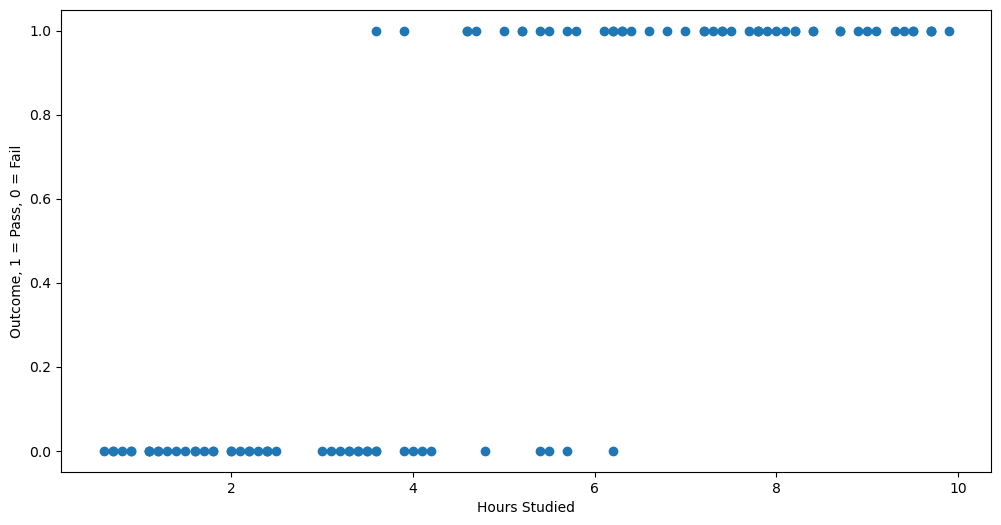

In [37]:
fig, axe = plt.subplots(1,1, figsize = (12,6))

X = df[['hours_revised']] 
y = df['pass_binary']

axe.scatter(X, y)
axe.set_xlabel("Hours Studied")
axe.set_ylabel("Outcome, 1 = Pass, 0 = Fail")

# Sigmoind Function 

This function, will have a horizontal asymptote at y = 1 and y=0, This is useful as it allows us to assign some probaility for the outcome ($0 \leq P \leq 1$), rather than using linear regression which gives us a nonsensical result.

\begin{align*}
\Huge \sigma(z) = \frac{1}{1+e^{-z}}
\end{align*}

# The Logistic Model

Z is the Logit, s.t $z = \theta_0 +\theta_1x$ 

$\theta$ is the parameter vector, The weights/coefficients learned by the model (e.g., $\theta_1 =$ weight for hours, $\theta_0 =$ intercept/bias).

$h_\theta(x)$ is th hypothesis function, the overall model prediction 


\begin{align*}
 z &= \theta^T x \\
 h_\theta(x) &= \sigma( \theta^T x)  \\
 P(y =1 | x) &= \frac{1}{1+e^{-(\theta_0+\theta_1x)}}
\end{align*}

changing the weight, $\theta_1$, changes the steeness of the curve 

changing the bias, $\theta_0$, shifts the curve

# Fitting the best curve

The best curve iss found using the Binary Cross-Entropy function. 
\begin{align*}
\Huge \text{Loss} = - \frac{1}{m} \sum_{i=1}^{m} \Big[ y^{(i)} \ln(h_\theta(x^{(i)})) + (1 - y^{(i)}) \ln(1 - h_\theta(x^{(i)})) \Big]
\end{align*}

* If $y = 1$ (Student Passed): The second term cancels out. If the model predicts $h_\theta(x) = 0.99$, $-\ln(0.99)$ is nearly $0$. If it predicts $0.01$, $-\ln(0.01)$ is a massive penalty.
* If $y = 0$ (Student Failed): The first term cancels out. Predicting $0.01$ gives near-zero loss, while predicting $0.99$ incurs a massive penalty.



Next we use Gradient Decent to fit the best curve, by solving for $\theta_0$ and $\theta_1$

In [38]:
X_train, X_test, y_tran, y_test = train_test_split(X,y, train_size = 0.8)

In [39]:
X_train.shape

(80, 1)

In [40]:
from sklearn.linear_model import LogisticRegression

In [60]:
model = LogisticRegression()
model.fit(X_train,y_train)
y_pred = model. predict(X_test)
accuracy = model.score(X_test, y_test)

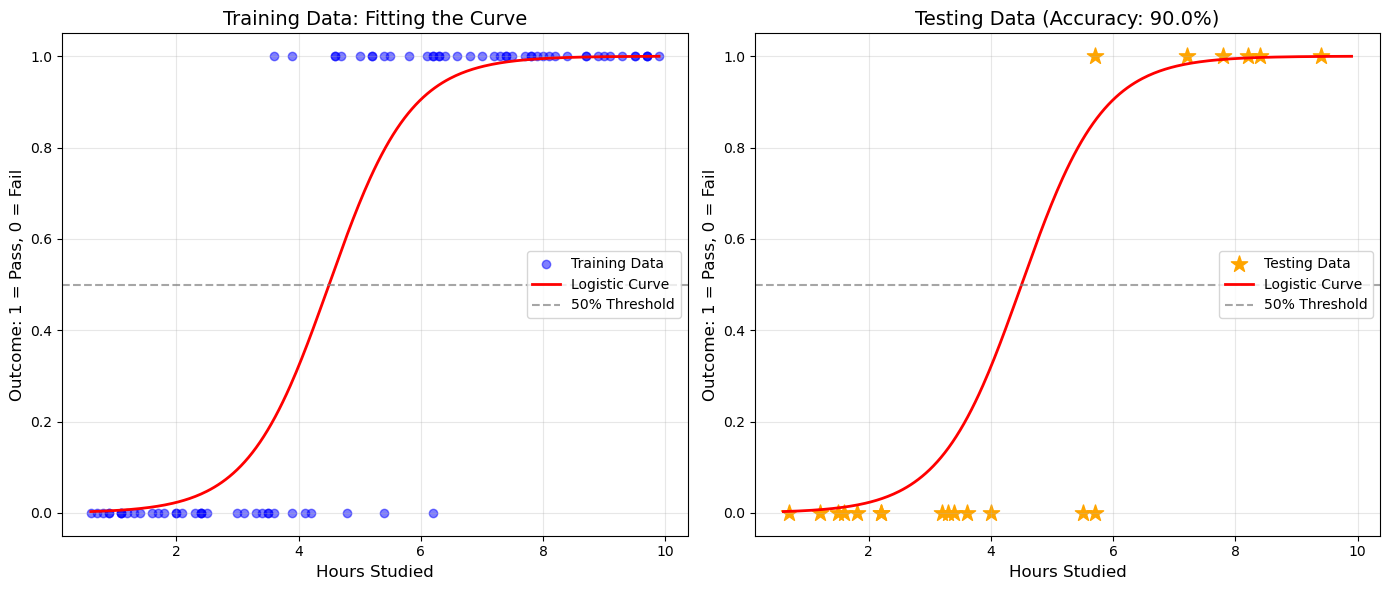

In [67]:
X_smooth = np.linspace(x_min, x_max, 300).reshape(-1, 1)

# Converting back to DataFrame to prevent Scikit-Learn warnings
X_smooth_df = pd.DataFrame(X_smooth, columns=['hours_revised'])
y_proba = model.predict_proba(X_smooth_df)[:, 1]

fig, axes = plt.subplots(1, 2, figsize=(14, 6))


axes[0].scatter(X_train, y_train, color='blue', alpha=0.5, label='Training Data')
axes[0].plot(X_smooth, y_proba, color='red', linewidth=2, label='Logistic Curve')
axes[0].axhline(0.5, color='gray', linestyle='--', alpha=0.7, label='50% Threshold')

axes[0].set_xlabel("Hours Studied", fontsize=12)
axes[0].set_ylabel("Outcome: 1 = Pass, 0 = Fail", fontsize=12)
axes[0].set_title("Training Data: Fitting the Curve", fontsize=14)
axes[0].legend(loc='center right')
axes[0].grid(True, alpha=0.3)

axes[1].scatter(X_test, y_test, color='orange', marker='*', s=150, label='Testing Data')
axes[1].plot(X_smooth, y_proba, color='red', linewidth=2, label='Logistic Curve')
axes[1].axhline(0.5, color='gray', linestyle='--', alpha=0.7, label='50% Threshold')

axes[1].set_xlabel("Hours Studied", fontsize=12)
axes[1].set_ylabel("Outcome: 1 = Pass, 0 = Fail", fontsize=12)
axes[1].set_title(f"Testing Data (Accuracy: {accuracy*100:.1f}%)", fontsize=14)
axes[1].legend(loc='center right')
axes[1].grid(True, alpha=0.3)

plt.tight_layout() 
plt.show()

# Evaluating the Model

## Confusion Matrix

To see how well our model fits we can look ata the confuison matrix

In [70]:
from sklearn.metrics import confusion_matrix

In [44]:
print(confusion_matrix(y_test, y_pred))

[[12  2]
 [ 0  6]]


$$\mathbf{M} = \begin{bmatrix} TP & FN \\ FP & TN \end{bmatrix}$$

The Components


*  True Positive ($TP$): Model predicted $1$, and actual label was $1$ (Correct).

* True Negative ($TN$): Model predicted $0$, and actual label was $0$ (Correct).

* False Positive ($FP$): Model predicted $1$, but actual label was $0$ (Type I Error).

* False Negative ($FN$): Model predicted $0$, but actual label was $1$ (Type II Error).



In [47]:
from sklearn.metrics import classification_report

In [48]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      0.86      0.92        14
           1       0.75      1.00      0.86         6

    accuracy                           0.90        20
   macro avg       0.88      0.93      0.89        20
weighted avg       0.93      0.90      0.90        20



# Multidimensional Data

This is done using the Softmax function instead of the Sigmoid Function 